# Peramalan Permintaan Mingguan (Forecasting) per Kategori Produk
**World Model for Business (Kasus Marketplace Olist)**  

---
Tujuan: Memprediksi volume unit terjual mingguan untuk kategori-kategori produk terbesar menggunakan evaluasi bertahap (*ladder of complexity*), serta menentukan apakah penambahan kompleksitas algoritma Machine Learning memberikan peningkatan akurasi yang nyata dibandingkan model baseline sederhana.

In [1]:
import sys
from pathlib import Path

root_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_dev_orders
from src.models.forecasting import aggregate_weekly_data, build_lag_features, evaluate_models

sns.set_theme(style='whitegrid', palette='muted')

df = load_dev_orders()
print(f'Total Data Dev : {len(df):,} baris')

Total Data Dev : 86,283 baris


## 1. Persiapan Data Deret Waktu Mingguan
Kita membatasi analisis pada 6 kategori produk dengan volume transaksi terbesar (`bed_bath_table`, `health_beauty`, `sports_leisure`, `furniture_decor`, `computers_accessories`, `housewares`) untuk memastikan kontinuitas deret waktu tanpa kekosongan data (*data sparsity*).

In [2]:
# Ekstraksi fitur time series di modul forecasting.py
weekly_df = aggregate_weekly_data(df, top_n_categories=6)
model_df = build_lag_features(weekly_df)

print("Sampel Data Fitur Lag:")
display(model_df.head(3))

Sampel Data Fitur Lag:


,primary_category,order_purchase_timestamp,unit_sold,avg_price,month,week_of_year,unit_lag_1,unit_lag_2,unit_lag_3,unit_lag_4
4,bed_bath_table,2017-02-06,37,92.052432,2,6,21.0,12.0,5.0,1.0
5,bed_bath_table,2017-02-13,40,109.827500,2,7,37.0,21.0,12.0,5.0
6,bed_bath_table,2017-02-20,37,142.808378,2,8,40.0,37.0,21.0,12.0


## 2. Perbandingan Kinerja Model (Validasi Bergulir / Rolling-Origin)
Evaluasi dilakukan secara bertahap (*ladder of complexity*) menggunakan metrik WAPE (*Weighted Absolute Percentage Error*):
1. **Baseline**: Prediksi penjualan minggu depan sama persis dengan penjualan minggu lalu (`Lag 1`).
2. **Statistik (Ridge)**: Regresi linear reguler dengan fitur kalender dan lag penjualan historis.
3. **Machine Learning (Random Forest)**: Model pohon ensemble non-linear dengan fitur lag yang sama.

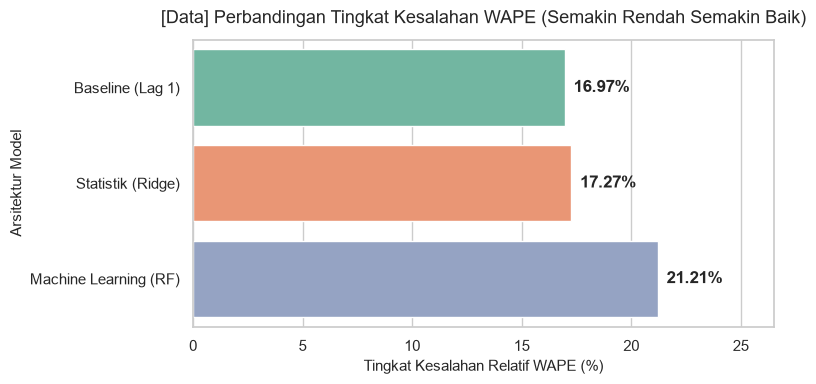

,Anak Tangga Model,WAPE (Error),WAPE (%)
0,Baseline (Lag 1),0.169694,16.969377
1,Statistik (Ridge),0.172657,17.265727
2,Machine Learning (RF),0.212122,21.212210


In [3]:
results = evaluate_models(model_df)

res_df = pd.DataFrame(list(results.items()), columns=['Anak Tangga Model', 'WAPE (Error)'])
res_df['WAPE (%)'] = res_df['WAPE (Error)'] * 100

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=res_df, x='WAPE (%)', y='Anak Tangga Model', hue='Anak Tangga Model', palette='Set2', legend=False)
plt.title('[Data] Perbandingan Tingkat Kesalahan WAPE (Semakin Rendah Semakin Baik)', fontsize=13, pad=12)
plt.xlim(0, res_df['WAPE (%)'].max() * 1.25)
for i, v in enumerate(res_df['WAPE (%)']):
    ax.text(v + 0.4, i, f'{v:.2f}%', va='center', fontweight='bold')
plt.xlabel('Tingkat Kesalahan Relatif WAPE (%)', fontsize=11)
plt.ylabel('Arsitektur Model', fontsize=11)
plt.tight_layout()
plt.show()

display(res_df)

---
## 3. Ringkasan Eksekutif & Pemilihan Model Produksi

Berdasarkan hasil validasi bergulir lintas waktu (*rolling-origin cross validation*):
- **Baseline (Lag 1)** menghasilkan tingkat kesalahan terendah yaitu **WAPE 17,0%** (0.1697).
- **Model Statistik (Ridge)** menghasilkan **WAPE 17,3%** (0.1727).
- **Machine Learning (Random Forest)** justru menghasilkan tingkat kesalahan tertinggi yaitu **WAPE 21,2%** (0.2121), mengindikasikan kecenderungan *overfitting* pada deret waktu mingguan yang berfluktuasi.

> **Rekomendasi Bisnis & Operasional**: Sesuai prinsip *Occam's Razor* dalam implementasi data science industri, model **Baseline (Lag-1)** direkomendasikan sebagai sistem peramalan produksi utama. Pendekatan ini memberikan akurasi tertinggi, tidak memerlukan beban komputasi pelatihan model yang rumit, dan sangat andal untuk estimasi kebutuhan kapasitas logistik mingguan.